### Direction Model

- Predicts direction given a move  
- Target is up vs down  

### Approach

- Train only on move samples  
- Same features as move model  
- Evaluate with AUC and stability  

### Goal

- Capture directional edge after activity  
- Combine with move model  

P(up) = P(move) * P(up | move)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from microstructure_alpha.data.loader import load_parquet_glob
from microstructure_alpha.features.feature_lists import MID_PRICE_MOVE_FINAL
from microstructure_alpha.models.model_configs import (
    calibrate_model,
    LINEAR_MODELS,
    TREE_MODELS,
    OTHER_MODELS,
)
from microstructure_alpha.models.train import run_model_parallel, run_fold
from microstructure_alpha.plots import plot_fold_aucs, plot_rolling_calibration
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
target = "mid_price_change_1_sign"

final_dataset = load_parquet_glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet",
    sort_by="timestamp",
)

### Target Setup

- Convert direction from -1 / 1 to 0 / 1  
- 0 = down, 1 = up  
- Makes it a standard binary classification problem

In [3]:
final_dataset[target] = final_dataset[target].replace(-1.0, 0.0)

### Features

- Use same features as move model
- Includes price, liquidity, imbalance, trade flow, volatility  

- Reuse validated feature set from EDA  
- No new feature engineering for direction model

In [4]:
from microstructure_alpha.features.feature_lists import (
    MID_PRICE_MOVE_FINAL,
    EDA_FEATURES,
)

all_vars = list(set(MID_PRICE_MOVE_FINAL + EDA_FEATURES))
all_vars = [
    "imbalance_5",
    "imbalance_1",
    "trade_volume_imbalance",
    "mid_minus_micro_log1p",
    "max_bid_ask_vol_ratio_log1p",
    "sell_volume_log1p",
    "lob_depth_ratio_3",
    "realized_vol_20_log1p",
    "log_return_2",
    "total_ask_volume_10_log1p",
    "total_bid_volume_10_log1p",
]

In [5]:
ALL_MODELS = {**LINEAR_MODELS, **TREE_MODELS, **OTHER_MODELS}

In [6]:
splits = 10
size_data = len(final_dataset)

tscv = TimeSeriesSplit(n_splits=splits, gap=50, max_train_size=int(size_data / splits))

In [7]:
X = final_dataset[all_vars]
y = final_dataset[target]
mask = final_dataset["mid_price_moves"] == 1

In [8]:
all_results = {}

for name, model in ALL_MODELS.items():

    scale = "logreg" in name
    calibrate = False  # not "logreg" in name
    all_results[name] = run_model_parallel(
        X,
        y,
        model,
        tscv,
        n_jobs=1,
        scale=scale,
        calibrate=calibrate,
        mask=mask,
    )

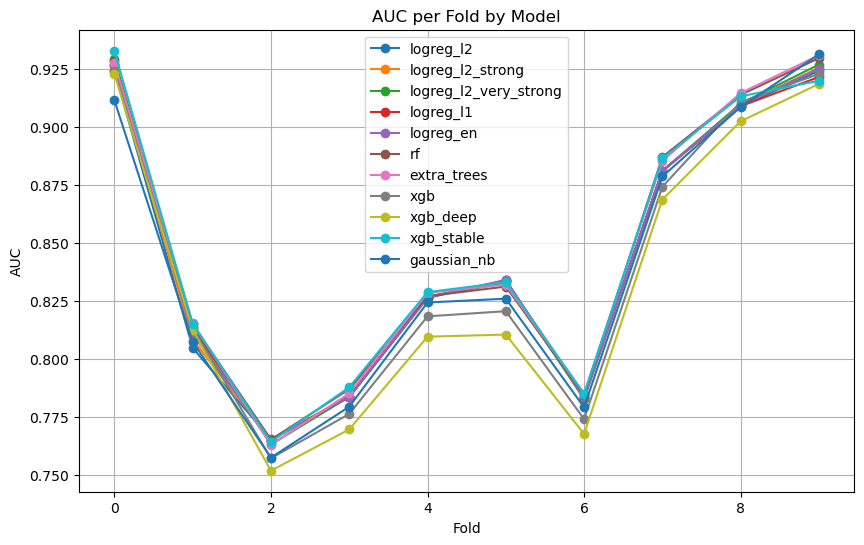

In [9]:
plt.figure(figsize=(10, 6))

for name, res in all_results.items():
    aucs = res["fold_aucs"]
    plt.plot(aucs, marker="o", label=name)

plt.xlabel("Fold")
plt.ylabel("AUC")
plt.title("AUC per Fold by Model")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
from microstructure_alpha.models.model_configs import build_model_summary

build_model_summary(all_results)

,mean_auc,std_auc,min_auc
model,,,
logreg_l2,0.843556,0.058264,0.765591
logreg_l2_strong,0.844386,0.058446,0.765382
logreg_l2_very_strong,0.845172,0.059161,0.763304
logreg_l1,0.844494,0.057627,0.765233
logreg_en,0.844586,0.058349,0.765072
rf,0.846952,0.059410,0.765408
extra_trees,0.846844,0.059817,0.763095
xgb,0.839252,0.060683,0.757356
xgb_deep,0.833519,0.061449,0.752003


### Model Summary

- All models very similar  
- Slight edge from tree models  
- XGBoost deep worse  
- Gaussian NB weakest  

Conclusion  
- Strong signal  
- Simple models already capture most of it

43999
43999


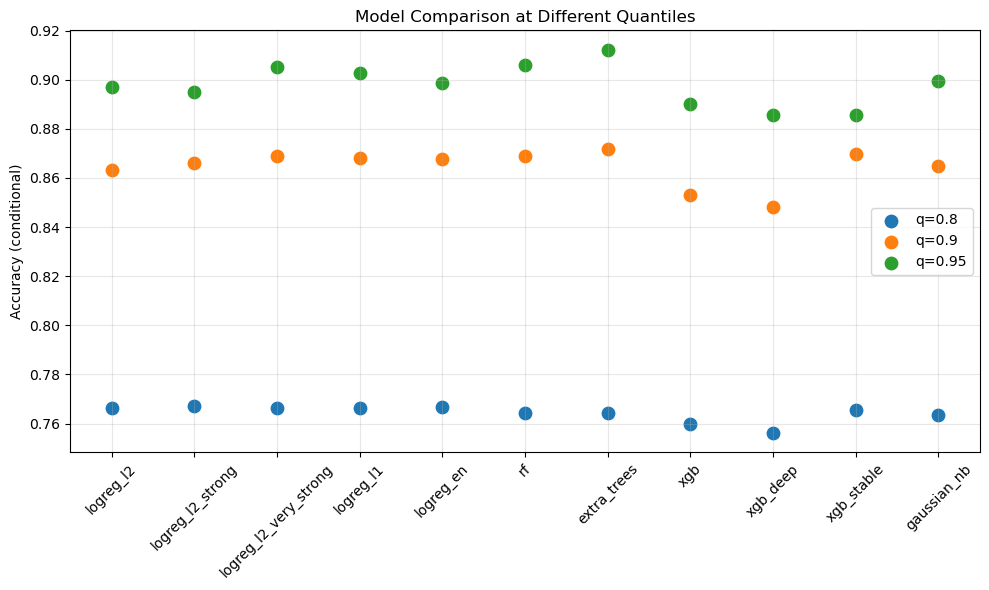

In [11]:
from microstructure_alpha.plots import plot_quantile_accuracy, plot_model_calibration

quantiles = [0.8, 0.9, 0.95]
y_true = y.values
print(len(y_true))
fold_oof = all_results["xgb"]["fold_oof"]
preds = np.nansum(fold_oof, axis=0)
print(len(preds))
# plot_model_calibration(all_results, y_true)
plot_quantile_accuracy(all_results, y_true, quantiles)

In [12]:
from microstructure_alpha.plots import plot_model_calibration

plot_model_calibration(
    all_results,
    y_true,
    window=500,
    figsize_per_model=3,
    show=False,
    save_path="C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\notebook_figs\\05_alpha_direction_model_figs\\comparison.pdf",
)

# feature selection

In [13]:
import pandas as pd

all_importance = {}

for name, res in all_results.items():
    coef_df = pd.DataFrame(res["coefs"], columns=X.columns)
    avg = coef_df.mean()
    all_importance[name] = avg

importance_df = pd.DataFrame(all_importance)

In [14]:
top_n = 130
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 500)

cols = {}

for model in importance_df.columns:
    sorted_feats = (
        importance_df[model].sort_values(key=abs, ascending=False).head(top_n)
    )
    cols[model] = sorted_feats.reset_index(drop=False)

out = pd.concat(cols, axis=1)


out

logreg_l2                       logreg_l2_strong  \
                          index logreg_l2                        index   
0                   imbalance_1  0.506068       trade_volume_imbalance   
1        trade_volume_imbalance  0.456751                  imbalance_1   
2         mid_minus_micro_log1p -0.400903        mid_minus_micro_log1p   
3                   imbalance_5  0.376360                  imbalance_5   
4   max_bid_ask_vol_ratio_log1p  0.249489  max_bid_ask_vol_ratio_log1p   
5             lob_depth_ratio_3  0.112476            lob_depth_ratio_3   
6             sell_volume_log1p -0.095853            sell_volume_log1p   
7                  log_return_2 -0.087519    total_bid_volume_10_log1p   
8     total_ask_volume_10_log1p  0.076819                 log_return_2   
9         realized_vol_20_log1p  0.066428        realized_vol_20_log1p   
10    total_bid_volume_10_log1p  0.009299    total_ask_volume_10_log1p   

                           logreg_l2_very_strong                        \
   logreg_l2_strong                        index logreg_l2_very_strong   
0          0.425161       trade_volume_imbalance              0.293017   
1          0.389131                  imbalance_1              0.271396   
2         -0.377902        mid_minus_micro_log1p             -0.270866   
3          0.330499                  imbalance_5              0.254776   
4          0.233550  max_bid_ask_vol_ratio_log1p              0.190909   
5          0.108303    total_bid_volume_10_log1p              0.167109   
6         -0.090975    total_ask_volume_10_log1p             -0.148234   
7          0.086827            lob_depth_ratio_3              0.103966   
8         -0.082212            sell_volume_log1p             -0.073819   
9          0.060314                 log_return_2             -0.037926   
10        -0.034481        realized_vol_20_log1p              0.036217   

                      logreg_l1                              logreg_en  \
                          index logreg_l1                        index   
0         mid_minus_micro_log1p -0.470950       trade_volume_imbalance   
1        trade_volume_imbalance  0.412411                  imbalance_1   
2                   imbalance_5  0.385701        mid_minus_micro_log1p   
3                   imbalance_1  0.313706                  imbalance_5   
4   max_bid_ask_vol_ratio_log1p  0.165456  max_bid_ask_vol_ratio_log1p   
5             lob_depth_ratio_3  0.071990    total_bid_volume_10_log1p   
6                  log_return_2 -0.052995            lob_depth_ratio_3   
7             sell_volume_log1p -0.051578            sell_volume_log1p   
8     total_bid_volume_10_log1p  0.041740                 log_return_2   
9         realized_vol_20_log1p  0.031355    total_ask_volume_10_log1p   
10    total_ask_volume_10_log1p -0.014474        realized_vol_20_log1p   

                                       rf            \
   logreg_en                        index        rf   
0   0.418456  max_bid_ask_vol_ratio_log1p  0.184140   
1   0.409057                  imbalance_5  0.157058   
2  -0.388870        mid_minus_micro_log1p  0.153713   
3   0.285220    total_ask_volume_10_log1p  0.137106   
4   0.196759                  imbalance_1  0.130448   
5   0.090480    total_bid_volume_10_log1p  0.116964   
6   0.088752       trade_volume_imbalance  0.038080   
7  -0.070844            lob_depth_ratio_3  0.037416   
8  -0.068996                 log_return_2  0.016406   
9  -0.055629            sell_volume_log1p  0.015243   
10  0.044029        realized_vol_20_log1p  0.013425   

                    extra_trees                                      xgb  \
                          index extra_trees                        index   
0                   imbalance_5    0.197085  max_bid_ask_vol_ratio_log1p   
1                   imbalance_1    0.194180                  imbalance_1   
2         mid_minus_micro_log1p    0.179255        mid_minus_micro_log1p   
3     total_ask_volume_10_log1p    0.

### Feature Importance

- Top features consistent across models  
- Imbalance, trade flow, and microprice dominate  

- Some variation across models, but core signals repeat  
- Confirms robustness of main feature groups  

Conclusion  
- Signal driven by a small set of key microstructure features  

In [15]:
final_features = [
    "imbalance_10",
    "imbalance_5",
    "max_bid_ask_vol_ratio_log1p",
    "total_bid_volume_10_log1p",
    "trade_count_log1p",
    "trade_count_imbalance",
    "microprice_change",
    "trade_volume_imbalance",
    "realized_vol_20_log1p",
    "trade_count_change",
    "rel_spread_log1p",
    "lob_depth_ratio_4",
    "mid_minus_micro_log1p",
]

### Sign Model Choice

XGB (stable) is chosen.

- More conservative - avoids overfitting on noisy, masked data  
- More stable probabilities - better for P(up | move)  
- Handles regime variation better  

high AUC